In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('C:/Users/eajaj/Downloads/resume-screening/data/Resume.csv')
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
df_des=pd.read_csv('C:/Users/eajaj/Downloads/resume-screening/data/monster_com-job_sample.csv')
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
print("\n--- Info for df (Resume.csv) ---")
df.info()

print("\n--- Descriptive Statistics for df (Resume.csv) ---")
df.describe()

print("\n--- Info for df_des (monster_com-job_sample.csv) ---")
df_des.info()

print("\n--- Descriptive Statistics for df_des (monster_com-job_sample.csv) ---")
df_des.describe()


--- Info for df (Resume.csv) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB

--- Descriptive Statistics for df (Resume.csv) ---

--- Info for df_des (monster_com-job_sample.csv) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          22000 non-null  object
 1   country_code     22000 non-null  object
 2   date_added       122 non-null    object
 3   has_expired      22000 non-null  object
 4   job_board        22000 non-null  object
 5   job_description  22000 non-n

,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
count,22000,22000,122,22000,22000,22000,22000,20372,22000,15133,22000,3446,16806,22000
unique,1,1,78,1,1,18744,18759,39,8423,738,22000,1737,163,22000
top,United States of America,US,9/22/2016,No,jobs.monster.com,12N Horizontal Construction Engineers Job Desc...,Monster,Full Time,"Dallas, TX",Healthcare Services,http://jobview.monster.com/Custodian-Lead-Job-...,"40,000.00 - 100,000.00 $ /year",Experienced (Non-Manager),1d37a888ca65fd919e459147a4c33457
freq,22000,22000,6,22000,22000,104,318,6757,646,1919,1,50,4594,1


In [5]:
print(df_des.columns)
print(df_des.info())

Index(['country', 'country_code', 'date_added', 'has_expired', 'job_board',
       'job_description', 'job_title', 'job_type', 'location', 'organization',
       'page_url', 'salary', 'sector', 'uniq_id'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          22000 non-null  object
 1   country_code     22000 non-null  object
 2   date_added       122 non-null    object
 3   has_expired      22000 non-null  object
 4   job_board        22000 non-null  object
 5   job_description  22000 non-null  object
 6   job_title        22000 non-null  object
 7   job_type         20372 non-null  object
 8   location         22000 non-null  object
 9   organization     15133 non-null  object
 10  page_url         22000 non-null  object
 11  salary           3446 non-null   object
 12  sector           16806 non-n

Preprocess Resume Text

In [6]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added this line to resolve the LookupError

def preprocess_text(text):
    # 1a. Convert to lowercase
    text = text.lower()

    # 1b. Remove URLs, email addresses, and phone numbers
    text = re.sub(r'http\S+|www\S+', '', text) # URLs
    text = re.sub(r'\S*@\S*\s?', '', text) # Email addresses
    # Basic phone number pattern (adjust if specific formats are known)
    text = re.sub(r'\(?\d{3}\)?[-\s]?\d{3}[-\s]?\d{4}', '', text)

    # 1c. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 1d. Remove special characters and numerical values, keeping only alphabetical characters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 1e. Tokenize the text
    tokens = word_tokenize(text)

    # 1f. Remove common English stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # 1g. Join the processed words back into a single string
    text = ' '.join(tokens)
    return text

# Apply the preprocessing function to the 'Resume_str' column
df['cleaned_resume_text'] = df['Resume_str'].apply(preprocess_text)

print("Preprocessing complete. Displaying first 5 rows with new 'cleaned_resume_text' column:")
print(df[['Resume_str', 'cleaned_resume_text']].head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\eajaj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\eajaj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\eajaj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Preprocessing complete. Displaying first 5 rows with new 'cleaned_resume_text' column:
                                          Resume_str  \
0           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1           HR SPECIALIST, US HR OPERATIONS      ...   
2           HR DIRECTOR       Summary      Over 2...   
3           HR SPECIALIST       Summary    Dedica...   
4           HR MANAGER         Skill Highlights  ...   

                                 cleaned_resume_text  
0  hr administratormarketing associate hr adminis...  
1  hr specialist us hr operations summary versati...  
2  hr director summary years experience recruitin...  
3  hr specialist summary dedicated driven dynamic...  
4  hr manager skill highlights hr skills hr depar...  


In [7]:
df_des['cleaned_job_description'] = df_des['job_description'].apply(preprocess_text)

print("Job description preprocessing complete. Displaying first 5 rows with new 'cleaned_job_description' column:")
print(df_des[['job_description', 'cleaned_job_description']].head())

Job description preprocessing complete. Displaying first 5 rows with new 'cleaned_job_description' column:
                                     job_description  \
0  TeamSoft is seeing an IT Support Specialist to...   
1  The Wisconsin State Journal is seeking a flexi...   
2  Report this job About the Job DePuy Synthes Co...   
3  Why Join Altec? If you’re considering a career...   
4  Position ID#  76162 # Positions  1 State  CT C...   

                             cleaned_job_description  
0  teamsoft seeing support specialist join client...  
1  wisconsin state journal seeking flexible motiv...  
2  report job job depuy synthes companies member ...  
3  join altec youre considering career altec inc ...  
4  position id positions state ct city fairfield ...  


Extract Skills from Resumes
Utilize NLP techniques to identify and extract relevant skills from the preprocessed resume text.

In [8]:
common_skills = [
    'python', 'java', 'c++', 'javascript', 'html', 'css', 'sql', 'r',
    'data analysis', 'machine learning', 'deep learning', 'artificial intelligence',
    'statistical analysis', 'data mining', 'big data', 'hadoop', 'spark', 'sas',
    'excel', 'tableau', 'power bi', 'aws', 'azure', 'google cloud', 'gcp',
    'docker', 'kubernetes', 'git', 'github', 'jenkins', 'devops',
    'project management', 'agile', 'scrum', 'leadership', 'communication',
    'teamwork', 'problem solving', 'critical thinking', 'creativity',
    'adaptability', 'time management', 'customer service', 'sales',
    'marketing', 'finance', 'accounting', 'human resources', 'hr', 'recruitment',
    'training', 'public speaking', 'negotiation', 'microsoft office', 'word', 'powerpoint',
    'outlook', 'unix', 'linux', 'windows', 'network security', 'cybersecurity',
    'web development', 'mobile development', 'frontend', 'backend', 'full stack',
    'database management', 'cloud computing', 'system administration', 'etl',
    'api development', 'data visualization', 'nlp', 'natural language processing',
    'software development', 'qa testing', 'technical support', 'business analysis',
    'strategic planning', 'risk management', 'financial modeling', 'budgeting'
]

def extract_skills_from_text(text, skills_list):
    extracted = []
    text_lower = text.lower()
    for skill in skills_list:
        if skill in text_lower:
            extracted.append(skill)
    return extracted

df['extracted_skills_resume'] = df['cleaned_resume_text'].apply(lambda x: extract_skills_from_text(x, common_skills))

print("Skills extraction complete. Displaying first 5 rows with 'cleaned_resume_text' and 'extracted_skills_resume' columns:")
print(df[['cleaned_resume_text', 'extracted_skills_resume']].head())

Skills extraction complete. Displaying first 5 rows with 'cleaned_resume_text' and 'extracted_skills_resume' columns:
                                 cleaned_resume_text  \
0  hr administratormarketing associate hr adminis...   
1  hr specialist us hr operations summary versati...   
2  hr director summary years experience recruitin...   
3  hr specialist summary dedicated driven dynamic...   
4  hr manager skill highlights hr skills hr depar...   

                             extracted_skills_resume  
0  [r, data analysis, aws, leadership, time manag...  
1  [r, git, project management, communication, sa...  
2  [r, sas, excel, project management, leadership...  
3  [r, excel, communication, customer service, hr...  
4  [r, excel, aws, project management, leadership...  


Extract Skills from Job Descriptions

In [9]:
df_des['extracted_skills_job_description'] = df_des['cleaned_job_description'].apply(lambda x: extract_skills_from_text(x, common_skills))

print("Skills extraction complete for job descriptions. Displaying first 5 rows with 'job_description' and 'extracted_skills_job_description' columns:")
print(df_des[['job_description', 'extracted_skills_job_description']].head())

Skills extraction complete for job descriptions. Displaying first 5 rows with 'job_description' and 'extracted_skills_job_description' columns:
                                     job_description  \
0  TeamSoft is seeing an IT Support Specialist to...   
1  The Wisconsin State Journal is seeking a flexi...   
2  Report this job About the Job DePuy Synthes Co...   
3  Why Join Altec? If you’re considering a career...   
4  Position ID#  76162 # Positions  1 State  CT C...   

                    extracted_skills_job_description  
0  [r, project management, communication, microso...  
1                                       [r, git, hr]  
2  [r, excel, aws, project management, agile, lea...  
3  [r, excel, communication, teamwork, customer s...  
4                  [r, aws, customer service, sales]  


Vectorize Text and Skills

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

def custom_tokenizer(text):
    return text.split()

tfidf_vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer, max_features=5000) # Limiting features to manage dimensionality

resume_text_vectors = tfidf_vectorizer.fit_transform(df['cleaned_resume_text'])
job_description_text_vectors = tfidf_vectorizer.transform(df_des['cleaned_job_description'])

print("TF-IDF vectorization complete.")
print(f"Shape of resume_text_vectors: {resume_text_vectors.shape}")
print(f"Shape of job_description_text_vectors: {job_description_text_vectors.shape}")

TF-IDF vectorization complete.
Shape of resume_text_vectors: (2484, 5000)
Shape of job_description_text_vectors: (22000, 5000)


Now that the TF-IDF vectorization for text is complete, I will define a function to convert the extracted skills into binary vectors and apply it to both the resume skills and job description skills columns, as specified in the instructions.

In [11]:
import numpy as np

def get_skill_vector(extracted_skills, all_common_skills):
    skill_vector = np.zeros(len(all_common_skills))
    for i, skill in enumerate(all_common_skills):
        if skill in extracted_skills:
            skill_vector[i] = 1
    return skill_vector

df['resume_skill_vectors'] = df['extracted_skills_resume'].apply(lambda x: get_skill_vector(x, common_skills))
df_des['job_description_skill_vectors'] = df_des['extracted_skills_job_description'].apply(lambda x: get_skill_vector(x, common_skills))

print("Skill vectorization complete.")
print(f"Shape of resume_skill_vectors (first row): {df['resume_skill_vectors'].iloc[0].shape}")
print(f"Shape of job_description_skill_vectors (first row): {df_des['job_description_skill_vectors'].iloc[0].shape}")
print("First 5 resume skill vectors:\n", df['resume_skill_vectors'].head())
print("First 5 job description skill vectors:\n", df_des['job_description_skill_vectors'].head())

Skill vectorization complete.
Shape of resume_skill_vectors (first row): (83,)
Shape of job_description_skill_vectors (first row): (83,)
First 5 resume skill vectors:
 0    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, ...
1    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...
2    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...
3    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...
4    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...
Name: resume_skill_vectors, dtype: object
First 5 job description skill vectors:
 0    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...
1    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...
2    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...
3    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...
4    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...
Name: job_description_skill_vectors, dtype: object


Calculate Similarity and Rank Candidates

In [12]:
from sklearn.metrics.pairwise import cosine_similarity

# 2. Calculate cosine similarity for text vectors
text_similarity_matrix = cosine_similarity(resume_text_vectors, job_description_text_vectors)

# 3. Convert skill vectors to 2D NumPy arrays
resume_skills_array = np.vstack(df['resume_skill_vectors'].values)
job_description_skills_array = np.vstack(df_des['job_description_skill_vectors'].values)

# 4. Calculate cosine similarity for skill vectors
skill_similarity_matrix = cosine_similarity(resume_skills_array, job_description_skills_array)

# 5. Combine the similarity matrices (e.g., by averaging)
overall_similarity_matrix = (text_similarity_matrix + skill_similarity_matrix) / 2

print("Similarity calculations complete.")
print(f"Shape of text_similarity_matrix: {text_similarity_matrix.shape}")
print(f"Shape of skill_similarity_matrix: {skill_similarity_matrix.shape}")
print(f"Shape of overall_similarity_matrix: {overall_similarity_matrix.shape}")

Similarity calculations complete.
Shape of text_similarity_matrix: (2484, 22000)
Shape of skill_similarity_matrix: (2484, 22000)
Shape of overall_similarity_matrix: (2484, 22000)


 extract similarity scores for all resumes against this job, create a DataFrame of resume IDs and scores, rank the resumes, and display the top 5, as per the instructions.

In [13]:
target_job_index = 0 # Selecting the first job description as the target
target_job_id = df_des.loc[target_job_index, 'uniq_id'] # Get the unique ID of the target job

# Extract similarity scores for the target job from overall_similarity_matrix
# The scores for a specific job are in a column of the matrix
resume_scores_for_target_job = overall_similarity_matrix[:, target_job_index]

# Create a Pandas DataFrame to store resume IDs and their scores
ranked_resumes = pd.DataFrame({
    'Resume_ID': df['ID'],
    'Similarity_Score': resume_scores_for_target_job
})

# Rank the resumes by sorting in descending order of similarity scores
ranked_resumes = ranked_resumes.sort_values(by='Similarity_Score', ascending=False)

print(f"Top 5 ranked resumes for Job ID: {target_job_id}")
print(ranked_resumes.head())


Top 5 ranked resumes for Job ID: 11d599f229a80023d2f40e7c52cd941e
      Resume_ID  Similarity_Score
90     17150707          0.383693
169    26622051          0.372985
137    44185767          0.369790
203    24583187          0.365334
1700   86828820          0.346152


Identify Skill Gaps

In [14]:
print("\n--- Identifying Skill Gaps for Top 5 Resumes ---")

# 1. Retrieve the extracted_skills_job_description for the target_job_index
target_job_skills = df_des.loc[target_job_index, 'extracted_skills_job_description']

# 2. Select the top 5 ranked resumes
top_5_resumes = ranked_resumes.head(5)

# 3. For each of these top 5 resumes:
for index, row in top_5_resumes.iterrows():
    resume_id = row['Resume_ID']

    # a. Find the corresponding row in the original df DataFrame to get its extracted_skills_resume
    resume_data = df[df['ID'] == resume_id].iloc[0] # Using iloc[0] as ID is unique
    resume_skills = resume_data['extracted_skills_resume']

    # c. Identify skills present in the job_description_skills but not in the resume_skills
    missing_skills = [skill for skill in target_job_skills if skill not in resume_skills]

    # d. Print the Resume_ID and its identified missing skills for the target job
    print(f"\nResume ID: {resume_id}")
    print(f"Job Skills: {target_job_skills}")
    print(f"Resume Skills: {resume_skills}")
    print(f"Missing Skills for Job ID {target_job_id}: {missing_skills}")


--- Identifying Skill Gaps for Top 5 Resumes ---

Resume ID: 17150707.0
Job Skills: ['r', 'project management', 'communication', 'microsoft office', 'technical support', 'business analysis']
Resume Skills: ['r', 'excel', 'project management', 'communication', 'human resources', 'hr', 'training', 'microsoft office', 'technical support']
Missing Skills for Job ID 11d599f229a80023d2f40e7c52cd941e: ['business analysis']

Resume ID: 26622051.0
Job Skills: ['r', 'project management', 'communication', 'microsoft office', 'technical support', 'business analysis']
Resume Skills: ['r', 'project management', 'microsoft office']
Missing Skills for Job ID 11d599f229a80023d2f40e7c52cd941e: ['communication', 'technical support', 'business analysis']

Resume ID: 44185767.0
Job Skills: ['r', 'project management', 'communication', 'microsoft office', 'technical support', 'business analysis']
Resume Skills: ['r', 'project management', 'agile', 'leadership', 'communication', 'sales', 'hr', 'training', 't

Visualize Candidate Rankings and Skills

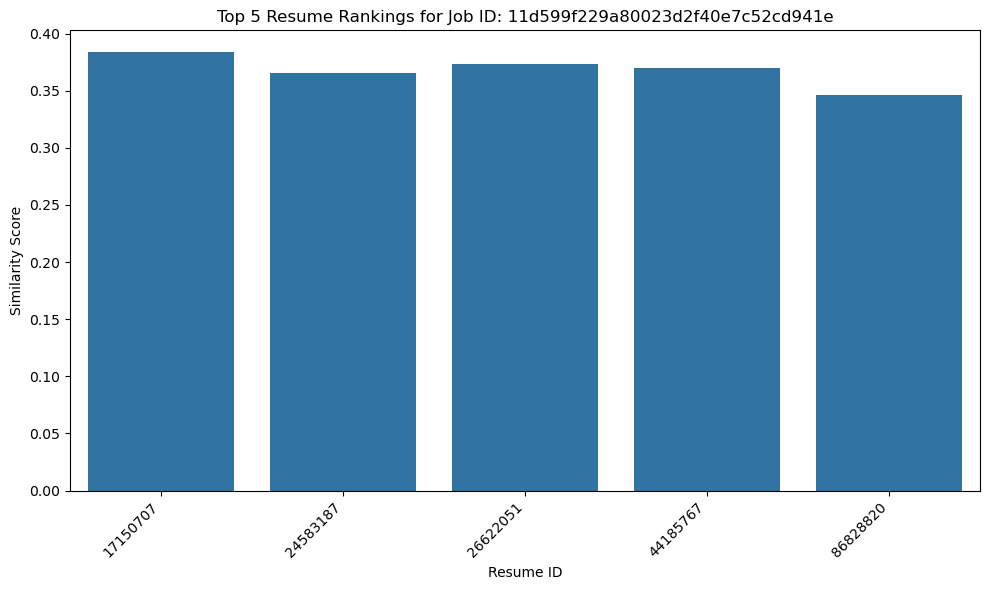

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Resume_ID', y='Similarity_Score', data=top_5_resumes)
plt.title(f'Top 5 Resume Rankings for Job ID: {target_job_id}')
plt.xlabel('Resume ID')
plt.ylabel('Similarity Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- Visualizing Skill Comparison ---



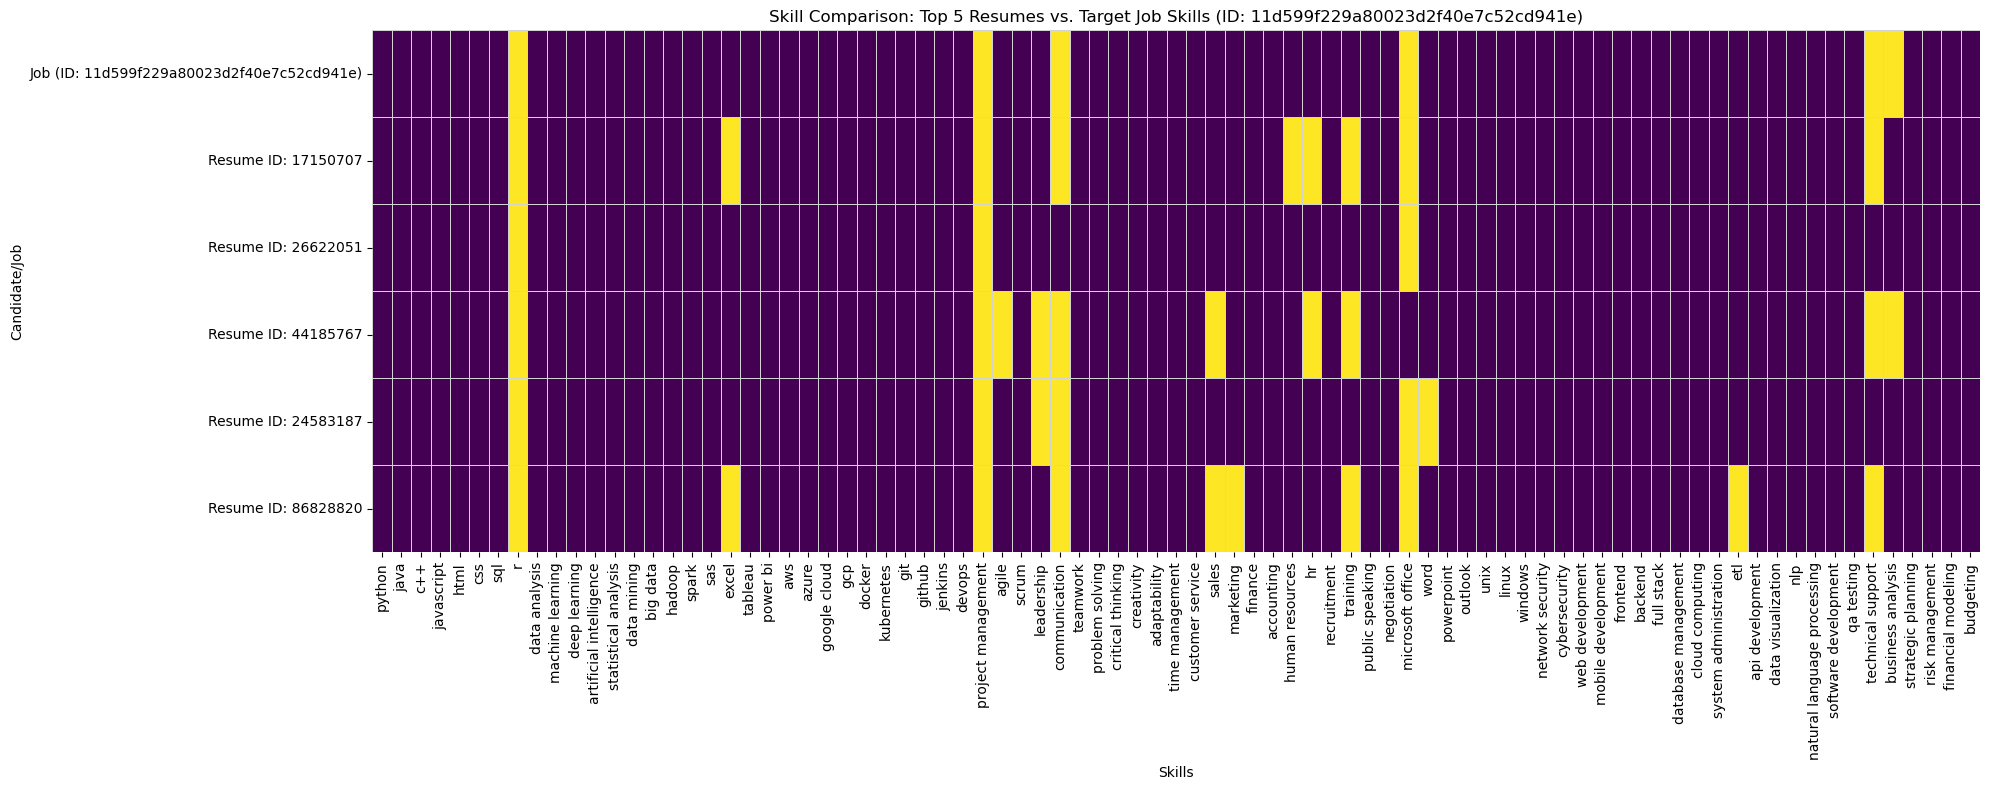

In [16]:
print("\n--- Visualizing Skill Comparison ---\n")

# Prepare data for heatmap

# 1. Get the target job's skills as a binary vector
target_job_skill_vector = df_des.loc[target_job_index, 'job_description_skill_vectors']

# Create a list to store skill data for heatmap
heatmap_data = []

# Add target job's skills to the heatmap data
job_skills_row = target_job_skill_vector.tolist()
heatmap_data.append(job_skills_row)

# 2. Extract skill vectors for the top 5 resumes
for index, row in top_5_resumes.iterrows():
    resume_id = row['Resume_ID']
    # Find the corresponding resume skill vector in the original df DataFrame
    resume_skill_vector = df[df['ID'] == resume_id]['resume_skill_vectors'].iloc[0]
    heatmap_data.append(resume_skill_vector.tolist())

# Create DataFrame for the heatmap
# Add 'Job (ID: target_job_id)' as the first row label
heatmap_row_labels = [f'Job (ID: {target_job_id})'] + [f'Resume ID: {int(row["Resume_ID"])}' for _, row in top_5_resumes.iterrows()]

skills_df = pd.DataFrame(heatmap_data, columns=common_skills, index=heatmap_row_labels)

# Create the heatmap
plt.figure(figsize=(20, 8))
sns.heatmap(skills_df, annot=False, cmap='viridis', cbar=False, linewidths=.5, linecolor='lightgray')
plt.title(f'Skill Comparison: Top 5 Resumes vs. Target Job Skills (ID: {target_job_id})')
plt.xlabel('Skills')
plt.ylabel('Candidate/Job')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()